# Hamiltonian Flow Matching - Fixed-Center Three-Body Co-Orbital Bridge

This notebook transports two moving bodies around a fixed central body.  The learned configuration is
`q = (q1_x, q1_y, q2_x, q2_y)`, while the third body stays pinned at the origin and only enters the
Hamiltonian.

The endpoint distributions are uniform squares around two co-orbital means.  The terminal means are a
counterclockwise rotation of the initial means by `alpha`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../../../'))

import math
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader,Dataset
from torchdyn.core import NeuralODE

from torchcfm.hamiltonian import (
    MeanStdBVPGaussianPath, flow_matching_loss,
    FixedCenterThreeBodyPotential,
    to_numpy, as_particles as _as_particles, make_hamiltonian_node, make_mean_std_bvp_path,
    solve_bvp_paths, train_on_cached_path_pairs, train_on_ot_pairs as _train_on_ot_pairs,
    simulate_model_trajectory, cached_mean_trajectory, trajectory_hamiltonian,
)
from torchcfm.optimal_transport import OTPlanSampler
from torchcfm.models.models_v2 import MLP
from torchcfm.utils import torch_wrapper

from ema_pytorch import EMA

if torch.cuda.is_available() and torch.cuda.device_count() > 2:
    device = torch.device('cuda:2')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')


In [48]:
torch.manual_seed(42)
np.random.seed(42)

# Learned state: two moving bodies in 2D.  The fixed central body is not part
# of the model state, but it appears in the Hamiltonian and plots.
n_moving = 2
particle_dim = 2
dim = n_moving * particle_dim

# Co-orbital bridge geometry.
r = 1
alpha = math.pi/2
square_width = 0.05
endpoint_distribution = "gaussian"
endpoint_std = square_width
fixed_position = torch.tensor([0.0, 0.0], device=device)

source_positions = torch.tensor(
    [[-2*r, 0.0], [-r, 0.0]],
    device=device,
    dtype=torch.get_default_dtype(),
)
rotation_matrix = torch.tensor(
    [
        [math.cos(alpha), -math.sin(alpha)],
        [math.sin(alpha), math.cos(alpha)],
    ],
    device=device,
    dtype=source_positions.dtype,
)
target_positions = source_positions @ rotation_matrix.T
source_mean = source_positions.reshape(-1)
target_mean = target_positions.reshape(-1)

# Hamiltonian constants.  `softening_epsilon` enters the softened distance
# sqrt(||x-y||^2 + epsilon^2).
G = 2.0
central_mass = 5.0
moving_mass = 1.0
softening_epsilon = 0.01

# Training controls. Increase n_dataset/n_epochs/n_iters for production runs.
batch_size = 64
n_dataset = 10_000
n_epochs = 10
n_iters = 800
n_warmup_iters = 5000
batch_size_warmup = 1024
lr = 5e-4
bvp_sigma = 0.01
quadrature_order = 3
n_steps = 150
tol = 1e-3
eval_batch = 100
diagnostic_batch = eval_batch
solve_t_span = torch.linspace(0, 1, n_steps + 1, device=device)

print(f'device: {device}')
print(f'dim: {dim}')
print(f'source means: {source_positions.tolist()}')
print(f'target means: {target_positions.tolist()}')
print(f'endpoint distribution: {endpoint_distribution}, endpoint_std: {endpoint_std}')
print(f'square width: {square_width}, alpha: {alpha:.4f} rad')

device: cuda:2
dim: 4
source means: [[-2.0, 0.0], [-1.0, 0.0]]
target means: [[-1.2246468525851679e-16, -2.0], [-6.123234262925839e-17, -1.0]]
endpoint distribution: gaussian, endpoint_std: 0.05
square width: 0.05, alpha: 1.5708 rad


## Softened Fixed-Center Three-Body Hamiltonian

For moving bodies `q1`, `q2` and fixed center `c`, the potential is

$$
V(q) = -\frac{GMm}{\sqrt{\|q_1-c\|^2+\epsilon^2}}
       -\frac{GMm}{\sqrt{\|q_2-c\|^2+\epsilon^2}}
       -\frac{Gm^2}{\sqrt{\|q_1-q_2\|^2+\epsilon^2}}.
$$

The BVP path uses `q'' = -\nabla V(q)`.

In [49]:
potential = FixedCenterThreeBodyPotential(
    fixed_position=fixed_position,
    G=G,
    central_mass=central_mass,
    moving_mass=moving_mass,
    epsilon=softening_epsilon,
)

q_test = source_mean.reshape(1, -1)
print(f"V(source_mean) = {potential.energy(q_test).item():.6f}")
print(f"force(source_mean) = {potential.force(q_test).reshape(n_moving, particle_dim)}")

V(source_mean) = -16.999336
force(source_mean) = tensor([[4.4996, -0.0000],
        [7.9988, -0.0000]], device='cuda:2')


In [50]:
class TotalDataset(Dataset):
        
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return self.samples.shape[0]
    def __getitem__(self,idx):
        return self.samples[idx]

source_dist = torch.distributions.Normal(source_mean, endpoint_std)
target_dist = torch.distributions.Normal(target_mean, endpoint_std)


source_data = source_dist.sample((n_dataset,))
target_data = target_dist.sample((n_dataset,))

source_loader = DataLoader(TotalDataset(source_data),batch_size = batch_size, shuffle = True, drop_last = True)
target_loader = DataLoader(TotalDataset(target_data),batch_size = batch_size, shuffle = True, drop_last = True)

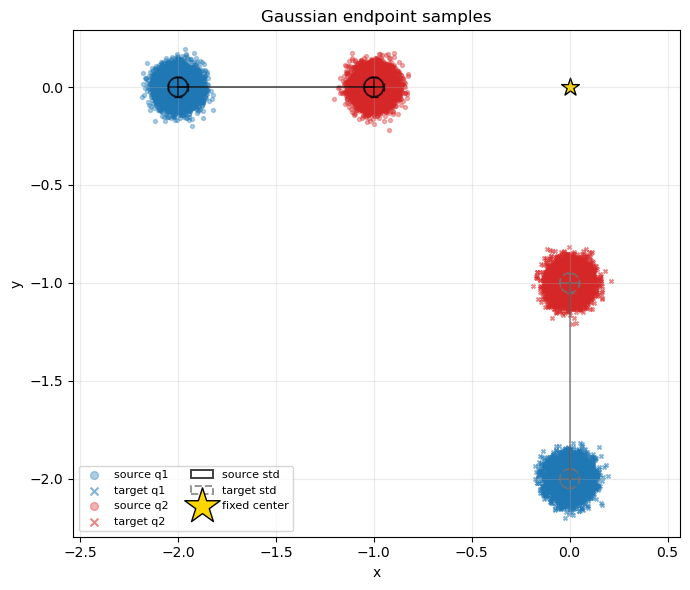

In [51]:


def sample_square_around(means, n, width=square_width):
    means = means.to(device)
    offsets = (torch.rand((n, *means.shape), device=device, dtype=means.dtype) - 0.5) * width
    return (means.unsqueeze(0) + offsets).reshape(n, -1)


def sample_endpoint(dist, means, n):
    if endpoint_distribution == "gaussian":
        return dist.sample((n,)).to(device)
    if endpoint_distribution == "uniform_square":
        return sample_square_around(means, n)
    raise ValueError(f"Unknown endpoint_distribution: {endpoint_distribution!r}")


def sample_source(n):
    return sample_endpoint(source_dist, source_positions, n)


def sample_target(n):
    return sample_endpoint(target_dist, target_positions, n)


def as_particles(q):
    return _as_particles(q, n_moving, particle_dim)


def particle_colors():
    return [plt.cm.tab10(0), plt.cm.tab10(3)]


def draw_endpoint_regions(ax):
    if endpoint_distribution == "gaussian":
        for positions, color, label, linestyle in [
            (to_numpy(source_positions), "black", "source std", "-"),
            (to_numpy(target_positions), "0.45", "target std", "--"),
        ]:
            for idx, center in enumerate(positions):
                ax.add_patch(
                    plt.Circle(
                        (center[0], center[1]),
                        endpoint_std,
                        fill=False,
                        color=color,
                        alpha=0.75,
                        linewidth=1.4,
                        linestyle=linestyle,
                        label=label if idx == 0 else None,
                    )
                )
                ax.errorbar(
                    center[0],
                    center[1],
                    xerr=endpoint_std,
                    yerr=endpoint_std,
                    fmt="none",
                    ecolor=color,
                    elinewidth=1.1,
                    capsize=3,
                    alpha=0.75,
                )
        return

    if endpoint_distribution == "uniform_square":
        half = square_width / 2.0
        for positions, color, label in [
            (to_numpy(source_positions), "black", "source square"),
            (to_numpy(target_positions), "0.45", "target square"),
        ]:
            for idx, center in enumerate(positions):
                rect = plt.Rectangle(
                    (center[0] - half, center[1] - half),
                    square_width,
                    square_width,
                    fill=False,
                    color=color,
                    alpha=0.65,
                    linewidth=1.4,
                    label=label if idx == 0 else None,
                )
                ax.add_patch(rect)
        return

    raise ValueError(f"Unknown endpoint_distribution: {endpoint_distribution!r}")


def endpoint_plot_title():
    if endpoint_distribution == "gaussian":
        return "Gaussian endpoint samples"
    if endpoint_distribution == "uniform_square":
        return "Uniform square endpoint samples"
    return f"Endpoint samples ({endpoint_distribution})"


def plot_endpoint_samples(x0, x1, title=None, n_show=500):
    x0p = to_numpy(as_particles(x0[:n_show]))
    x1p = to_numpy(as_particles(x1[:n_show]))
    colors = particle_colors()

    fig, ax = plt.subplots(figsize=(7, 6))
    for i, color in enumerate(colors):
        ax.scatter(x0p[:, i, 0], x0p[:, i, 1], s=8, color=color, alpha=0.35, label=f"source q{i + 1}")
        ax.scatter(x1p[:, i, 0], x1p[:, i, 1], s=8, color=color, marker="x", alpha=0.55, label=f"target q{i + 1}")
    draw_endpoint_regions(ax)
    ax.scatter([fixed_position[0].item()], [fixed_position[1].item()], marker="*", s=180, color="gold", edgecolor="black", label="fixed center")
    ax.plot(to_numpy(source_positions[:, 0]), to_numpy(source_positions[:, 1]), color="black", linewidth=1.4, alpha=0.6)
    ax.plot(to_numpy(target_positions[:, 0]), to_numpy(target_positions[:, 1]), color="0.35", linewidth=1.4, alpha=0.6)
    ax.axis("equal")
    ax.grid(alpha=0.25)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title or endpoint_plot_title())
    ax.legend(markerscale=2, fontsize=8, ncols=2)
    plt.tight_layout()
    plt.show()


x0_vis = source_data
x1_vis = target_data
plot_endpoint_samples(x0_vis, x1_vis,n_show = n_dataset)

## BVP Path, Models, and Training Helpers

The nonlinear reference path is solved with `MeanStdBVPGaussianPath`.  Its cache stores successful
endpoint pairs, and training samples `(x_t, u_t)` from those cached BVP paths.

In [52]:
ot_sampler = OTPlanSampler(method='exact')

fwd_model = MLP(dim, out_dim=dim, w=256, time_varying=True).to(device)
bwd_model = MLP(dim, out_dim=dim, w=256, time_varying=True).to(device)

fwd_optimizer = torch.optim.Adam(fwd_model.parameters(), lr=lr)
bwd_optimizer = torch.optim.Adam(bwd_model.parameters(), lr=lr)

fwd_losses = []
bwd_losses = []


def make_node(model):
    return make_hamiltonian_node(model)


def make_path():
    return make_mean_std_bvp_path(
        potential,
        sigma=bvp_sigma,
        n_steps=n_steps,
        tol=tol,
        quadrature_order=quadrature_order,
    )


def solve_paths(x0, x1, label="path"):
    return solve_bvp_paths(make_path, x0, x1, label=label, description="fixed-center three-body BVPs")


def train_on_cached_paths(model, optimizer, path, x0, x1, n_steps_train, label, log_every=200):
    return train_on_cached_path_pairs(
        model, optimizer, path, x0, x1, n_steps_train, label,
        batch_size=batch_size,
        device=device,
        log_every=log_every,
        no_pairs_message="no successful BVP pairs to train on",
    )


def train_on_ot_pairs(model, optimizer, x0, x1, n_steps_train, label, log_every=500):
    return _train_on_ot_pairs(
        model, optimizer, x0, x1, n_steps_train, label,
        batch_size=batch_size,
        device=device,
        log_every=log_every,
    )

## Initial BVP Dataset

In [53]:
x0_all = sample_source(batch_size)
x1_all = sample_target(batch_size)
x0_coupled, x1_coupled = ot_sampler.sample_plan(x0_all, x1_all)
path, x0_coupled, x1_coupled, states = solve_paths(x0_coupled, x1_coupled, label='initial')
n_dataset = x0_coupled.shape[0]

plot_idx = np.linspace(0, n_dataset - 1, min(6, n_dataset)).astype(int)
t_state = to_numpy(path.t_grid)
colors = particle_colors()



Solving 64 initial fixed-center three-body BVPs...
initial: kept 63 / 64 BVPs; failed 1; states: torch.Size([63, 151, 10])
initial: first failures: [(2, 'The maximum number of mesh nodes is exceeded.')]


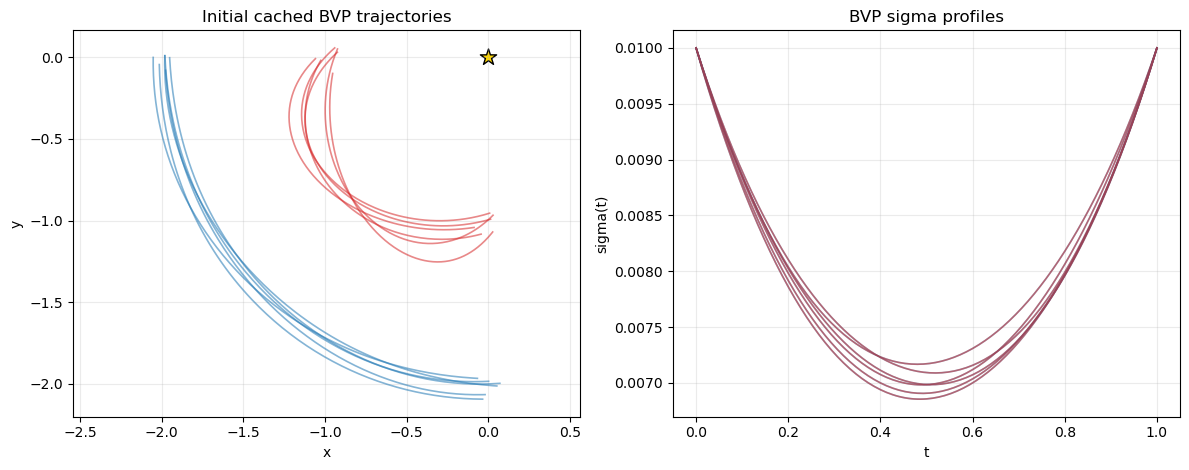

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for idx in plot_idx:
    q_path = to_numpy(as_particles(states[idx, :, :dim]))
    sigma = to_numpy(states[idx,:,2*dim])
    # speed = np.linalg.norm(to_numpy(states[idx, :, dim:]).reshape(n_steps + 1, n_moving, particle_dim), axis=-1)
    # axes[0].plot(q_path[:,0],q_path[:,1],linewidth = 1.8,alpha = 0.8, label= f'path {idx}')
    
    for pidx, color in enumerate(colors):
        axes[0].plot(q_path[:, pidx, 0], q_path[:, pidx, 1], color=color, alpha=0.55, linewidth=1.2)
        axes[1].plot(t_state, sigma, color=color, alpha=0.55, linewidth=1.2)
    # axes[1].plot(t_state, speed.mean(axis=-1), alpha=0.75)

axes[0].scatter([fixed_position[0].item()], [fixed_position[1].item()], marker='*', s=150, color='gold', edgecolor='black')
axes[0].axis('equal')
axes[0].grid(alpha=0.25)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Initial cached BVP trajectories')
axes[1].set_xlabel('t')
axes[1].set_ylabel('sigma(t)')
axes[1].set_title('BVP sigma profiles')
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Warm Start on Straight OT Pairs

In [66]:
warm_x0 = sample_source(batch_size_warmup)
warm_x1 = sample_target(batch_size_warmup)
warm_x0, warm_x1 = ot_sampler.sample_plan(warm_x0, warm_x1)

print('Warm-start forward model on straight OT pairs...')
fwd_losses.extend(train_on_ot_pairs(fwd_model, fwd_optimizer, warm_x0, warm_x1, n_warmup_iters, 'fwd warm'))
print('Warm-start backward model on straight OT pairs...')
bwd_losses.extend(train_on_ot_pairs(bwd_model, bwd_optimizer, warm_x1, warm_x0, n_warmup_iters, 'bwd warm'))

Warm-start forward model on straight OT pairs...
fwd warm step     0: loss = 1.28506
fwd warm step   500: loss = 0.00032
fwd warm step  1000: loss = 0.00027
fwd warm step  1500: loss = 0.00029
fwd warm step  2000: loss = 0.00033
fwd warm step  2500: loss = 0.00026
fwd warm step  3000: loss = 0.00029
fwd warm step  3500: loss = 0.00044
fwd warm step  4000: loss = 0.00026
fwd warm step  4500: loss = 0.00030
fwd warm step  4999: loss = 0.00035
Warm-start backward model on straight OT pairs...
bwd warm step     0: loss = 1.19793
bwd warm step   500: loss = 0.00041
bwd warm step  1000: loss = 0.00044
bwd warm step  1500: loss = 0.00035
bwd warm step  2000: loss = 0.00028
bwd warm step  2500: loss = 0.00040
bwd warm step  3000: loss = 0.00042
bwd warm step  3500: loss = 0.00040
bwd warm step  4000: loss = 0.00029
bwd warm step  4500: loss = 0.00028
bwd warm step  4999: loss = 0.00038


## Alternating Forward/Backward Training

In [67]:
ema_beta = 0.99
ema_update_after_step = 0
ema_update_every = 5
ema_freeze_batches = 0
ema_diag_every = ema_update_every


def mean_param_delta(model, ema_model):
    deltas = []
    with torch.no_grad():
        for param, ema_param in zip(model.parameters(), ema_model.parameters()):
            deltas.append((param - ema_param).abs().mean())
    if not deltas:
        return 0.0
    return torch.stack(deltas).mean().item()


def print_ema_diagnostic(context, generation_model=None):
    fwd_step = int(fwd_ema.step.item()) if fwd_ema is not None else -1
    bwd_step = int(bwd_ema.step.item()) if bwd_ema is not None else -1
    fwd_delta = mean_param_delta(fwd_model, fwd_ema.ema_model) if fwd_ema is not None else float('nan')
    bwd_delta = mean_param_delta(bwd_model, bwd_ema.ema_model) if bwd_ema is not None else float('nan')
    generation = f', generation={generation_model}' if generation_model is not None else ''
    print(
        f'{context}: fwd_ema_step={fwd_step}, bwd_ema_step={bwd_step}, '
        f'fwd_delta={fwd_delta:.3e}, bwd_delta={bwd_delta:.3e}{generation}'
    )


fwd_ema = EMA(
    fwd_model,
    beta=ema_beta,
    update_after_step=ema_update_after_step,
    update_every=ema_update_every,
    min_value=ema_beta,
).to(device)
# bwd_ema = None
bwd_ema = EMA(
    bwd_model,
    beta=ema_beta,
    update_after_step=ema_update_after_step,
    update_every=ema_update_every,
    min_value=ema_beta,
).to(device)

# Initialize EMA from the warm-started online models once, then let the slow schedule control drift.
fwd_ema.update()
bwd_ema.update()
print_ema_diagnostic('EMA initialized from warm-start models')


EMA initialized from warm-start models: fwd_ema_step=1, bwd_ema_step=1, fwd_delta=0.000e+00, bwd_delta=0.000e+00


In [68]:
last_fwd_path = None
last_bwd_path = None
last_fwd_states = None
last_bwd_states = None
last_fwd_x0, last_fwd_x1 = None, None
last_bwd_x0, last_bwd_x1 = None, None
ema_alternating_updates = 0

for epoch in range(n_epochs):
    # print(f'\n=== Alternating epoch {epoch + 1} / {n_epochs} ===')
    i = 0
    for x_source,y_target in zip(source_loader,target_loader):
        i += 1
        if i % 2 == 0:
            # Train fwd using couplings induced by the current bwd NODE.
            # y_target = sample_target(n_dataset)
            if bwd_ema is not None:
                bwd_ema.ema_model.eval()
                bwd_node = make_node(bwd_ema.ema_model)
                generation_model = 'bwd_ema.ema_model'
            else:
                bwd_model.eval()
                bwd_node = make_node(bwd_model)
                generation_model = 'bwd_model'
            with torch.no_grad():
                bwd_traj = bwd_node.trajectory(y_target, t_span=solve_t_span)
            generated_source = bwd_traj[-1].detach()

            last_fwd_path, last_fwd_x0, last_fwd_x1, last_fwd_states = solve_paths(
                generated_source,
                y_target,
                label=f'epoch {epoch} batch {i} fwd',
            )
            fwd_losses.extend(
                train_on_cached_paths(
                    fwd_model,
                    fwd_optimizer,
                    last_fwd_path,
                    last_fwd_x0,
                    last_fwd_x1,
                    n_iters,
                    label=f'epoch {epoch} batch {i} fwd',
                )
            )
            ema_alternating_updates += 1
            if fwd_ema is not None and ema_alternating_updates > ema_freeze_batches:
                fwd_ema.update()
            if ema_alternating_updates % ema_diag_every == 0:
                print_ema_diagnostic(f'epoch {epoch} batch {i} post-fwd', generation_model)
        else:
            # Train bwd using couplings induced by the current fwd NODE.
            # x_source = sample_source(n_dataset)
            if fwd_ema is not None:
                fwd_ema.ema_model.eval()
                fwd_node = make_node(fwd_ema.ema_model)
                generation_model = 'fwd_ema.ema_model'
            else:
                fwd_model.eval()
                fwd_node = make_node(fwd_model)
                generation_model = 'fwd_model'
            with torch.no_grad():
                fwd_traj = fwd_node.trajectory(x_source, t_span=solve_t_span)
            generated_target = fwd_traj[-1].detach()

            last_bwd_path, last_bwd_x0, last_bwd_x1, last_bwd_states = solve_paths(
                generated_target,
                x_source,
                label=f'epoch {epoch} batch {i} bwd',
            )
            bwd_losses.extend(
                train_on_cached_paths(
                    bwd_model,
                    bwd_optimizer,
                    last_bwd_path,
                    last_bwd_x0,
                    last_bwd_x1,
                    n_iters,
                    label=f'epoch {epoch} batch {i} bwd',
                )
            )
            ema_alternating_updates += 1
            if bwd_ema is not None and ema_alternating_updates > ema_freeze_batches:
                bwd_ema.update()
            if ema_alternating_updates % ema_diag_every == 0:
                print_ema_diagnostic(f'epoch {epoch} batch {i} post-bwd', generation_model)

Solving 64 epoch 0 batch 1 bwd fixed-center three-body BVPs...
epoch 0 batch 1 bwd: kept 63 / 64 BVPs; failed 1; states: torch.Size([63, 151, 10])
epoch 0 batch 1 bwd: first failures: [(52, 'The maximum number of mesh nodes is exceeded.')]
epoch 0 batch 1 bwd step     0: loss = 0.86624
epoch 0 batch 1 bwd step   200: loss = 0.00773
epoch 0 batch 1 bwd step   400: loss = 0.00359
epoch 0 batch 1 bwd step   600: loss = 0.00386
epoch 0 batch 1 bwd step   799: loss = 0.00234
Solving 64 epoch 0 batch 2 fwd fixed-center three-body BVPs...
epoch 0 batch 2 fwd: kept 63 / 64 BVPs; failed 1; states: torch.Size([63, 151, 10])
epoch 0 batch 2 fwd: first failures: [(35, 'The maximum number of mesh nodes is exceeded.')]
epoch 0 batch 2 fwd step     0: loss = 0.93145
epoch 0 batch 2 fwd step   200: loss = 0.01040
epoch 0 batch 2 fwd step   400: loss = 0.00303
epoch 0 batch 2 fwd step   600: loss = 0.00392
epoch 0 batch 2 fwd step   799: loss = 0.00341
Solving 64 epoch 0 batch 3 bwd fixed-center three-

KeyboardInterrupt: 

In [69]:
# last_fwd_path = None
# last_bwd_path = None
# last_fwd_states = None
# last_bwd_states = None
# last_fwd_x0, last_fwd_x1 = None, None
# last_bwd_x0, last_bwd_x1 = None, None

# for epoch in range(n_epochs):
#     print(f'\n=== Alternating epoch {epoch + 1} / {n_epochs} ===')

#     if epoch % 2 == 0:
#         # Train fwd using couplings induced by the current bwd NODE.
#         y_target = sample_target(n_dataset)
#         bwd_model.eval()
#         bwd_node = make_node(bwd_model)
#         with torch.no_grad():
#             bwd_traj = bwd_node.trajectory(y_target, t_span=solve_t_span)
#         generated_source = bwd_traj[-1].detach()

#         last_fwd_path, last_fwd_x0, last_fwd_x1, last_fwd_states = solve_paths(
#             generated_source,
#             y_target,
#             label=f'epoch {epoch} fwd',
#         )
#         fwd_losses.extend(
#             train_on_cached_paths(
#                 fwd_model,
#                 fwd_optimizer,
#                 last_fwd_path,
#                 last_fwd_x0,
#                 last_fwd_x1,
#                 n_iters,
#                 label=f'epoch {epoch} fwd',
#             )
#         )
#     else:
#         # Train bwd using couplings induced by the current fwd NODE.
#         x_source = sample_source(n_dataset)
#         fwd_model.eval()
#         fwd_node = make_node(fwd_model)
#         with torch.no_grad():
#             fwd_traj = fwd_node.trajectory(x_source, t_span=solve_t_span)
#         generated_target = fwd_traj[-1].detach()

#         last_bwd_path, last_bwd_x0, last_bwd_x1, last_bwd_states = solve_paths(
#             generated_target,
#             x_source,
#             label=f'epoch {epoch} bwd',
#         )
#         bwd_losses.extend(
#             train_on_cached_paths(
#                 bwd_model,
#                 bwd_optimizer,
#                 last_bwd_path,
#                 last_bwd_x0,
#                 last_bwd_x1,
#                 n_iters,
#                 label=f'epoch {epoch} bwd',
#             )
#         )

## Training Losses

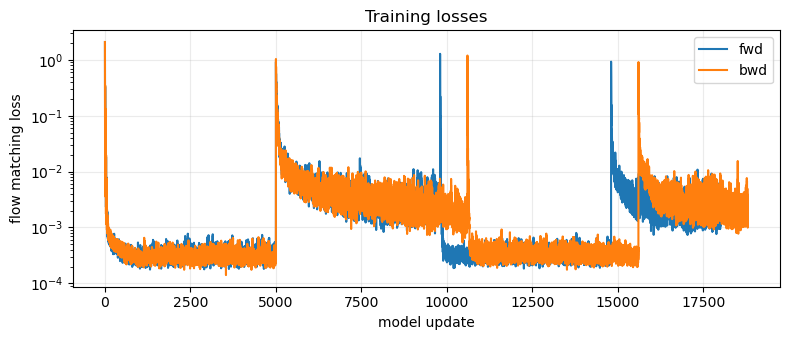

In [70]:
plt.figure(figsize=(8, 3.5))
plt.semilogy(fwd_losses, label='fwd')
plt.semilogy(bwd_losses, label='bwd')
plt.xlabel('model update')
plt.ylabel('flow matching loss')
plt.title('Training losses')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## Learned Flow Evaluation

In [74]:
# fwd_ema.ema_model.eval()
# bwd_ema.ema_model.eval()
# fwd_node = make_node(fwd_ema.ema_model)
# bwd_node = make_node(bwd_ema.ema_model)
fwd_model.eval()
bwd_model.eval()
fwd_node = make_node(fwd_model)
bwd_node = make_node(bwd_model)
eval_t_span = torch.linspace(0, 1, 100, device=device)

x0_eval = sample_source(eval_batch*50)
x1_eval = sample_target(eval_batch*50)

with torch.no_grad():
    fwd_traj = fwd_node.trajectory(x0_eval, t_span=eval_t_span)
    bwd_traj = bwd_node.trajectory(x1_eval, t_span=eval_t_span)

# fwd_traj = to_numpy(fwd_traj)
# bwd_traj = to_numpy(bwd_traj)

In [75]:
def simulate_model(model, x0, t_span):
    node = make_node(model)
    model.eval()
    with torch.no_grad():
        traj = node.trajectory(x0.to(device), t_span.to(device))
    return traj


# eval_t_span = torch.linspace(0, 1, 101, device=device)


# fwd_traj = simulate_model(fwd_model, x0_eval, eval_t_span)
# bwd_traj = simulate_model(bwd_model, x1_eval, eval_t_span)


def print_endpoint_summary(label, traj, reference_mean, reference_positions):
    terminal = traj[-1]
    generated_mean = terminal.mean(dim=0)
    mean_rmse = (generated_mean - reference_mean.to(device=terminal.device, dtype=terminal.dtype)).pow(2).mean().sqrt().item()
    print(f"{label} terminal mean RMSE: {mean_rmse:.4f}")

    if endpoint_distribution == "gaussian":
        generated_std = terminal.std(dim=0, unbiased=True).mean().item()
        print(f"{label} average coordinate std: {generated_std:.4f} (target {endpoint_std:.4f})")
        return

    if endpoint_distribution == "uniform_square":
        terminal_particles = as_particles(terminal)
        target = reference_positions.to(device=terminal.device, dtype=terminal.dtype)
        lower = target - square_width / 2.0
        upper = target + square_width / 2.0
        inside = ((terminal_particles >= lower.unsqueeze(0)) & (terminal_particles <= upper.unsqueeze(0))).float().mean().item()
        print(f"{label} terminal coordinate fraction inside target squares: {inside:.4f}")
        return

    raise ValueError(f"Unknown endpoint_distribution: {endpoint_distribution!r}")


print_endpoint_summary("Forward", fwd_traj, target_mean, target_positions)
print_endpoint_summary("Backward", bwd_traj, source_mean, source_positions)

Forward terminal mean RMSE: 0.0340
Forward average coordinate std: 0.0506 (target 0.0500)
Backward terminal mean RMSE: 0.0345
Backward average coordinate std: 0.0508 (target 0.0500)


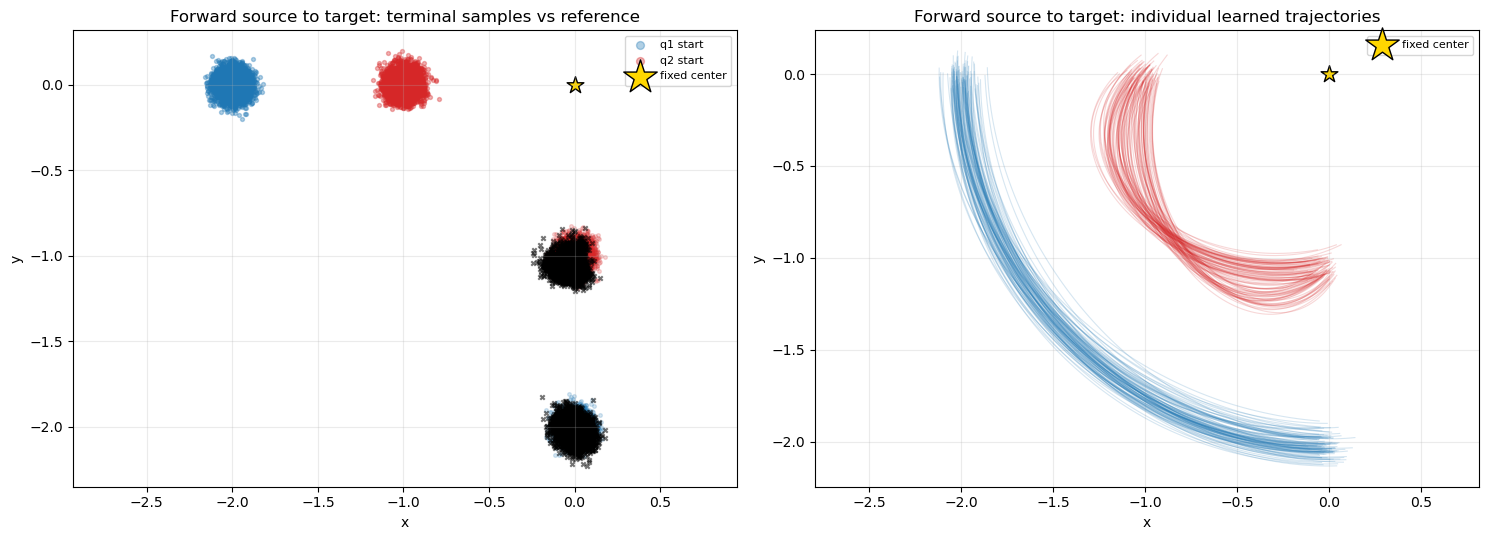

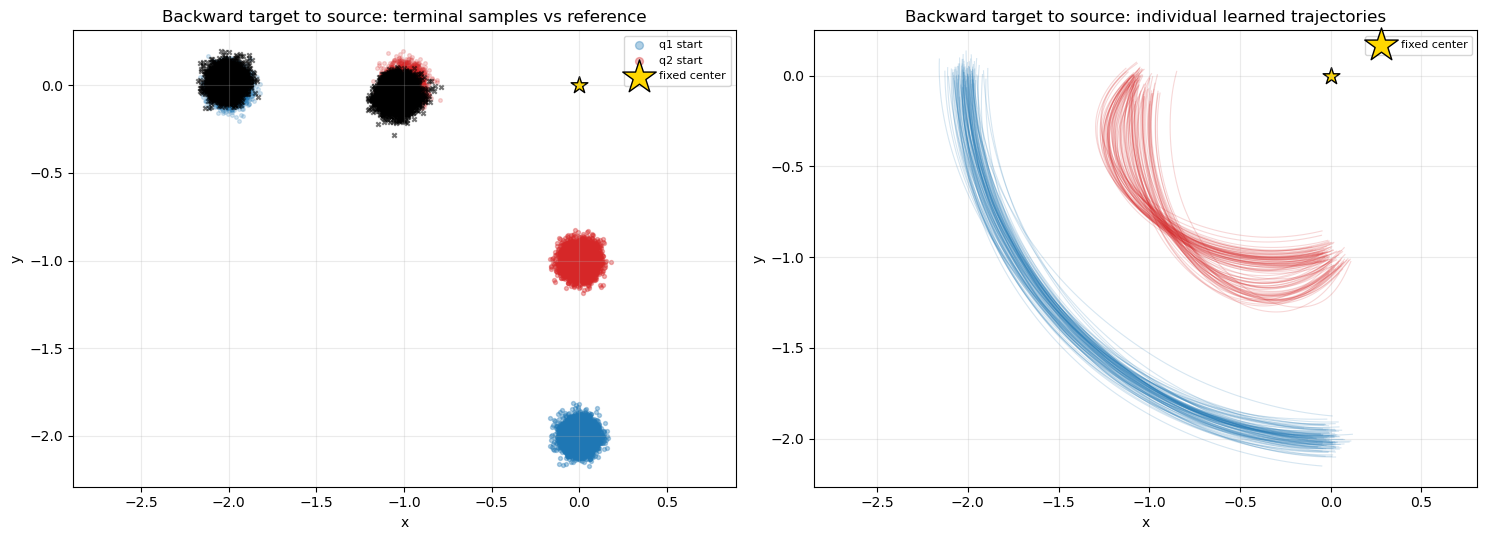

In [76]:
def plot_learned_three_body_trajectories(traj, reference, title, n_show=500, n_lines=100):
    n_show = min(n_show, traj.shape[1], reference.shape[0])
    n_lines = min(n_lines, traj.shape[1])
    traj_particles = to_numpy(as_particles(traj.detach().cpu()))
    ref_particles = to_numpy(as_particles(reference.detach().cpu()))
    colors = particle_colors()

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    for pidx, color in enumerate(colors):
        axes[0].scatter(traj_particles[0, :n_show, pidx, 0], traj_particles[0, :n_show, pidx, 1], s=8, color=color, alpha=0.35, label=f'q{pidx + 1} start')
        axes[0].scatter(ref_particles[:n_show, pidx, 0], ref_particles[:n_show, pidx, 1], s=7, color=color, alpha=0.18)
        axes[0].scatter(traj_particles[-1, :n_show, pidx, 0], traj_particles[-1, :n_show, pidx, 1], s=10, color='black', marker='x', alpha=0.55)
    # draw_endpoint_squares(axes[0])
    axes[0].set_title(f'{title}: terminal samples vs reference')

    for i in range(n_lines):
        for pidx, color in enumerate(colors):
            axes[1].plot(traj_particles[:, i, pidx, 0], traj_particles[:, i, pidx, 1], color=color, alpha=0.18, linewidth=0.8)
        # axes[1].plot(traj_particles[:, i, :, 0].T, traj_particles[:, i, :, 1].T, color='0.35', alpha=0.025, linewidth=0.5)
    axes[1].set_title(f'{title}: individual learned trajectories')

    for ax in axes:
        ax.scatter([fixed_position[0].item()], [fixed_position[1].item()], marker='*', s=160, color='gold', edgecolor='black', label='fixed center')
        ax.axis('equal')
        ax.grid(alpha=0.25)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.legend(markerscale=2, fontsize=8)

    plt.tight_layout()
    plt.show()


plot_learned_three_body_trajectories(fwd_traj, x1_eval, 'Forward source to target',n_show = fwd_traj.shape[1])
plot_learned_three_body_trajectories(bwd_traj, x0_eval, 'Backward target to source',n_show = bwd_traj.shape[1])

## Forward NODE vs Direct Hamiltonian BVP

Forward NODE vs direct BVP trajectory RMSE: 1.521794e-02
Comparison BVPs kept: 97 / 100


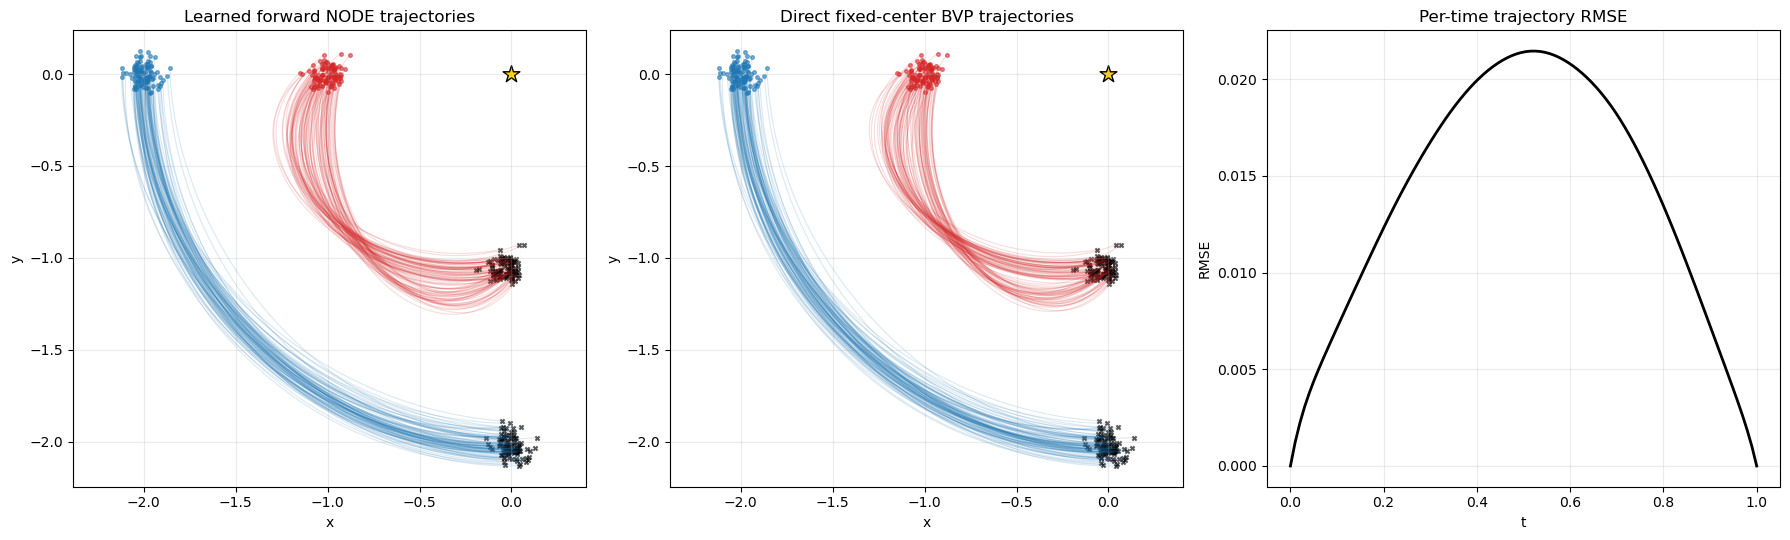

In [77]:
comparison_batch = min(eval_batch, fwd_traj.shape[1])
learned_traj = fwd_traj[:, :comparison_batch]
x0_cmp = x0_eval[:comparison_batch]
generated_target = learned_traj[-1].detach()

cmp_path = make_path()
cmp_path.batch_solve(x0_cmp, generated_target)
keep = cmp_path.success_mask.to(device=device)
x0_cmp_keep = x0_cmp[keep]
generated_target_keep = generated_target[keep]
learned_traj_keep = learned_traj[:, keep]
if x0_cmp_keep.shape[0] == 0:
    raise RuntimeError('No successful comparison BVPs.')
closed_form_traj = cached_mean_trajectory(cmp_path, x0_cmp_keep, generated_target_keep, eval_t_span)

per_time_rmse = (learned_traj_keep - closed_form_traj).pow(2).mean(dim=(1, 2)).sqrt()
trajectory_rmse = per_time_rmse.pow(2).mean().sqrt().item()
print(f'Forward NODE vs direct BVP trajectory RMSE: {trajectory_rmse:.6e}')
print(f'Comparison BVPs kept: {x0_cmp_keep.shape[0]} / {comparison_batch}')

n_compare_lines = min(100, x0_cmp_keep.shape[0])
learned_particles = to_numpy(as_particles(learned_traj_keep[:, :n_compare_lines]))
closed_particles = to_numpy(as_particles(closed_form_traj[:, :n_compare_lines]))
time_rmse = to_numpy(per_time_rmse)
t_eval_plot = to_numpy(eval_t_span)
colors = particle_colors()

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for i in range(n_compare_lines):
    for pidx, color in enumerate(colors):
        axes[0].plot(learned_particles[:, i, pidx, 0], learned_particles[:, i, pidx, 1], color=color, alpha=0.16, linewidth=0.8)
        axes[1].plot(closed_particles[:, i, pidx, 0], closed_particles[:, i, pidx, 1], color=color, alpha=0.16, linewidth=0.8)

for pidx, color in enumerate(colors):
    axes[0].scatter(learned_particles[0, :, pidx, 0], learned_particles[0, :, pidx, 1], s=7, color=color, alpha=0.55)
    axes[0].scatter(learned_particles[-1, :, pidx, 0], learned_particles[-1, :, pidx, 1], s=9, color='black', marker='x', alpha=0.65)
    axes[1].scatter(closed_particles[0, :, pidx, 0], closed_particles[0, :, pidx, 1], s=7, color=color, alpha=0.55)
    axes[1].scatter(closed_particles[-1, :, pidx, 0], closed_particles[-1, :, pidx, 1], s=9, color='black', marker='x', alpha=0.65)

axes[0].set_title('Learned forward NODE trajectories')
axes[1].set_title('Direct fixed-center BVP trajectories')
axes[2].plot(t_eval_plot, time_rmse, color='black', linewidth=2.0)
axes[2].set_xlabel('t')
axes[2].set_ylabel('RMSE')
axes[2].set_title('Per-time trajectory RMSE')
axes[2].grid(alpha=0.25)

for ax in axes[:2]:
    ax.scatter([fixed_position[0].item()], [fixed_position[1].item()], marker='*', s=160, color='gold', edgecolor='black')
    ax.axis('equal')
    ax.grid(alpha=0.25)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
plt.show()

## Hamiltonian Diagnostics

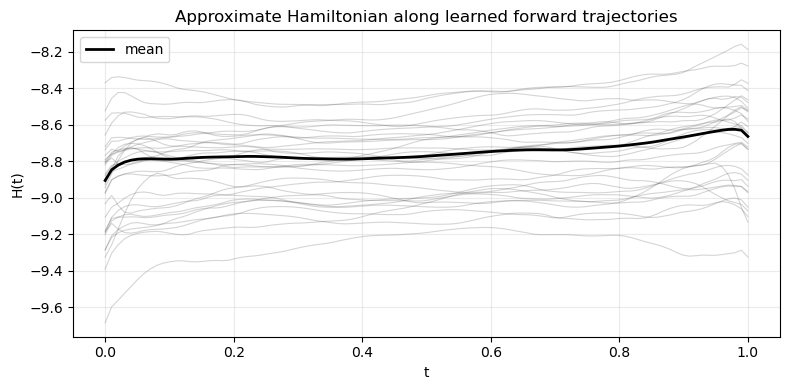

In [78]:
def trajectory_hamiltonian_per_sample(traj, t_span, potential):
    dt = t_span[1] - t_span[0]
    velocity = torch.empty_like(traj)
    velocity[0] = (traj[1] - traj[0]) / dt
    velocity[-1] = (traj[-1] - traj[-2]) / dt
    velocity[1:-1] = (traj[2:] - traj[:-2]) / (2.0 * dt)
    kinetic = 0.5 * velocity.pow(2).sum(dim=-1)
    potential_energy = torch.stack([potential.energy(x_t) for x_t in traj], dim=0)
    return kinetic + potential_energy


diagnostic_count = min(diagnostic_batch, fwd_traj.shape[1])
H = trajectory_hamiltonian_per_sample(fwd_traj[:, :diagnostic_count], eval_t_span, potential)
H_np = to_numpy(H)
n_hamiltonian_traces = min(30, diagnostic_count, H_np.shape[1])

plt.figure(figsize=(8, 4))
plt.plot(to_numpy(eval_t_span), H_np[:, :n_hamiltonian_traces], color="0.25", alpha=0.22, linewidth=0.8)
plt.plot(to_numpy(eval_t_span), H_np.mean(axis=1), color="black", linewidth=2.0, label="mean")
plt.xlabel("t")
plt.ylabel("H(t)")
plt.title("Approximate Hamiltonian along learned forward trajectories")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()